In [4]:
import pandas as pd

df = pd.read_csv("../data/processed/epiclim_dengue_monthly_cleaned.csv")
df.head()

,state_ut,district,year_month,Latitude,Longitude,Cases,Deaths,preci,LAI,Temp,Cases_MA_3,Deaths_MA_3,Case_Growth_Rate,Month,Season
0,Andaman and Nicobar Islands,Andaman,2019-06,13.511120,92.917388,8.0,0.0,0.772605,33.0,301.720000,8.0,0.0,0.000000,6,Monsoon
1,Andaman and Nicobar Islands,Andaman,2019-10,13.511120,92.917388,30.0,0.0,0.149858,42.0,298.906667,19.0,0.0,2.750000,10,Post-Monsoon
2,Andaman and Nicobar Islands,North and Middle Andaman,2013-12,12.611239,92.831654,86.0,0.0,0.188149,53.0,298.200000,86.0,0.0,0.000000,12,Winter
3,Andhra Pradesh,Anantapur,2010-06,14.654623,77.556260,68.0,0.0,0.254048,0.0,311.175000,68.0,0.0,0.000000,6,Monsoon
4,Andhra Pradesh,Anantapur,2011-06,14.654623,77.556260,232382.0,0.0,0.027715,0.0,307.820000,116225.0,0.0,3416.382353,6,Monsoon


In [6]:
df.columns

Index(['state_ut', 'district', 'year_month', 'Latitude', 'Longitude', 'Cases',
       'Deaths', 'preci', 'LAI', 'Temp', 'Cases_MA_3', 'Deaths_MA_3',
       'Case_Growth_Rate', 'Month', 'Season'],
      dtype='object')

In [8]:
features = df[['Cases', 'preci', 'Temp', 'Cases_MA_3', 'Case_Growth_Rate']]
features.head()

,Cases,preci,Temp,Cases_MA_3,Case_Growth_Rate
0,8.0,0.772605,301.720000,8.0,0.000000
1,30.0,0.149858,298.906667,19.0,2.750000
2,86.0,0.188149,298.200000,86.0,0.000000
3,68.0,0.254048,311.175000,68.0,0.000000
4,232382.0,0.027715,307.820000,116225.0,3416.382353


In [10]:
features = features.fillna(0)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [14]:
import numpy as np

print(np.isinf(features).sum())
print(features.isnull().sum())

Cases               0
preci               0
Temp                0
Cases_MA_3          0
Case_Growth_Rate    1
dtype: int64
Cases               0
preci               0
Temp                0
Cases_MA_3          0
Case_Growth_Rate    0
dtype: int64


In [16]:
features = features.replace([np.inf, -np.inf], np.nan)

In [18]:
features = features.fillna(0)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

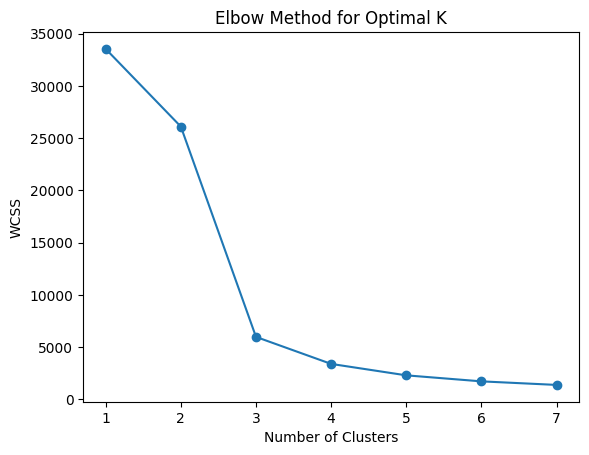

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,8), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [24]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

df[['district', 'Cluster']].head()

,district,Cluster
0,Andaman,0
1,Andaman,0
2,North and Middle Andaman,0
3,Anantapur,0
4,Anantapur,0


In [26]:
cluster_means = df.groupby('Cluster')['Cases'].mean().sort_values()

print(cluster_means)

Cluster
0    7.777747e+20
2    6.436019e+35
1    1.191160e+44
Name: Cases, dtype: float64


In [28]:
risk_mapping = {
    cluster_means.index[0]: 'Low Risk',
    cluster_means.index[1]: 'Medium Risk',
    cluster_means.index[2]: 'High Risk'
}

df['Risk_Level'] = df['Cluster'].map(risk_mapping)

df[['district', 'Risk_Level']].head()

,district,Risk_Level
0,Andaman,Low Risk
1,Andaman,Low Risk
2,North and Middle Andaman,Low Risk
3,Anantapur,Low Risk
4,Anantapur,Low Risk


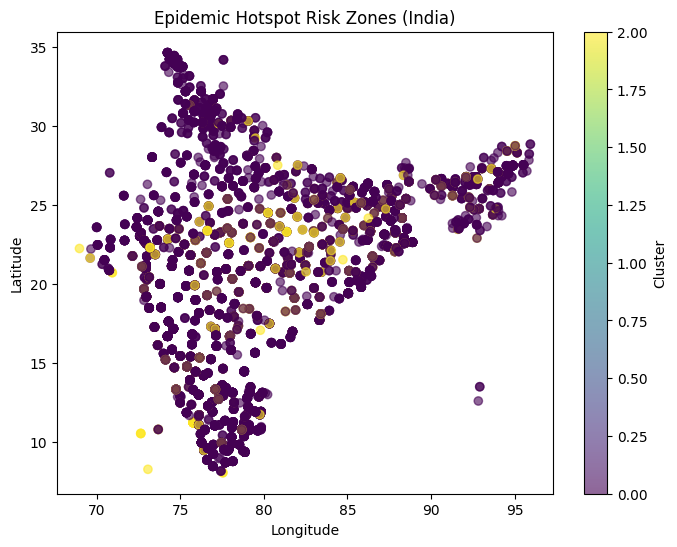

In [30]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(df['Longitude'], df['Latitude'], 
                      c=df['Cluster'], cmap='viridis', alpha=0.6)

plt.colorbar(scatter, label='Cluster')
plt.title("Epidemic Hotspot Risk Zones (India)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [31]:
df.to_csv("../data/processed/epiclim_with_hotspots.csv", index=False)